<a href="https://colab.research.google.com/github/hanil975/CV-2026-H11/blob/main/CVLAB_Practical2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Required Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

Converting the Image to Grayscale

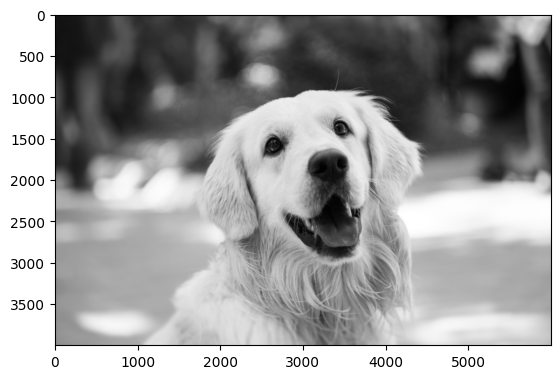

In [ ]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread('/content/pexels-svetozar-milashevich-1490908.jpg',cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Image not found or could not be loaded.")
else:
    plt.imshow(img, cmap='gray')
    plt.show()

Creating the Salt Pepper Function

In [4]:
def add_salt_pepper_noise(img, probability = 0.3):
    noisy = img.copy()
    random = np.random.rand(*img.shape)

    noisy[random < (probability / 2)] = 0
    noisy[random > 1 - (probability / 2)] = 255

    return noisy

Defining the Probability and Calling the Function

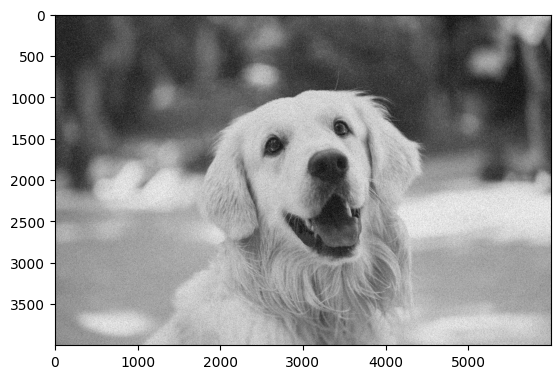

In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('/content/pexels-svetozar-milashevich-1490908.jpg',cv2.IMREAD_GRAYSCALE)

probability = 0.2

if img is None:
    print("Cannot apply salt and pepper noise: Image 'img' is None. Please ensure an image is loaded correctly.")
else:
    noisy = add_salt_pepper_noise(img, probability)
    plt.imshow(noisy, cmap='gray')
    plt.show()

Code to show a transition from 0 noise to 1.0 noise

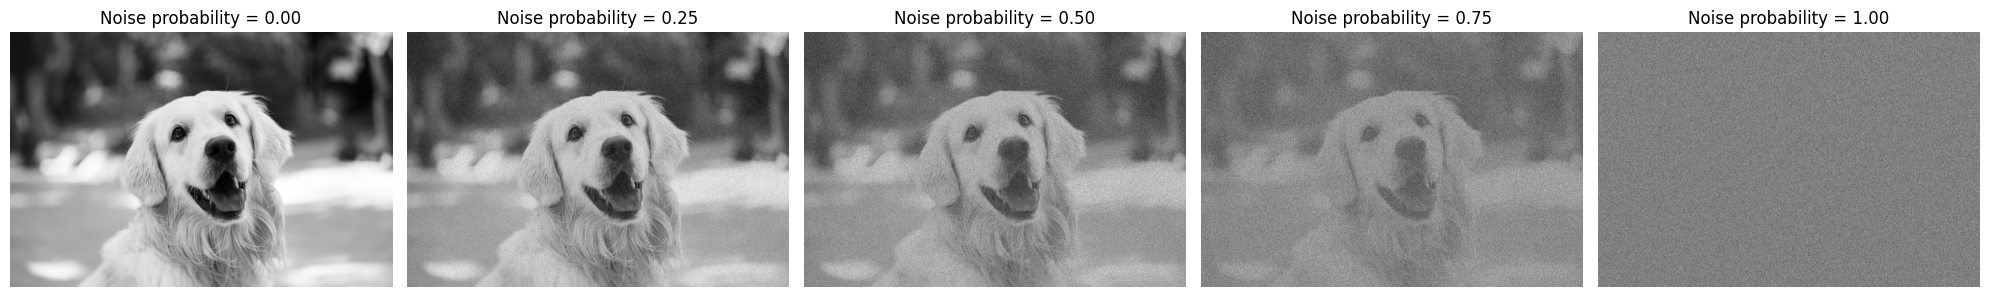

In [8]:
import numpy as np
import matplotlib.pyplot as plt

probabilities = np.arange(0, 1.1, 0.25)  # from 0.00 to 1.00

fig, axes = plt.subplots(1, len(probabilities), figsize=(20, 4))

for ax, p in zip(axes, probabilities):
    noisy = add_salt_pepper_noise(img, p)
    ax.imshow(noisy, cmap='gray')
    ax.set_title(f"Noise probability = {p:.2f}")
    ax.axis('off')

plt.tight_layout()
plt.show()

Using the Moving Window to remove the Salt Pepper Noise

In [9]:
def median_filter(img, window_size=3):
    pad = window_size // 2
    padded = cv2.copyMakeBorder(img, pad, pad, pad, pad, cv2.BORDER_REFLECT)
    result = np.zeros_like(img, dtype=np.uint8)

    h = 785
    w = 516
    for i in range(h):
        for j in range(w):
            window = padded[i:i+window_size, j:j+window_size]
            result[i, j] = np.median(window)

    return result

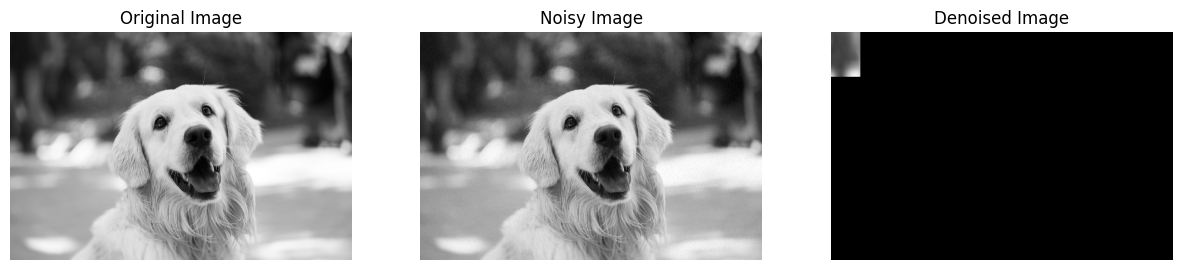

In [10]:
probability = 0.04
noisy = add_salt_pepper_noise(img, probability)
denoised = median_filter(noisy, 3)
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(noisy, cmap='gray')
plt.title('Noisy Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(denoised, cmap='gray')
plt.title('Denoised Image')
plt.axis('off')

plt.show()